# 08. Literature Synthesis for Causal Assumptions

Literature synthesis for causal inference is an assumption-review task. The goal is to turn outside evidence into a disciplined assumption review: what prior work says about plausible confounders, mechanisms, measurement, interference, external validity, and likely failure modes.

In industry settings, this matters because business data rarely arrives with random assignment. Analysts often need to justify why a design is credible, what remains uncertain, and which sensitivity analyses are required. AI can help organize the evidence, but it must be forced to cite sources and to separate evidence from causal conclusions.


## Mathematical Core

Literature synthesis can be treated as evidence aggregation over assumptions. Let $a$ be an assumption, such as overlap or no interference, and let $E_1, \ldots, E_K$ be extracted evidence snippets. A simple support score is

$$
S(a) = \frac{1}{K} \sum_{k=1}^{K} w_k \; s(E_k, a),
$$

where $s(E_k, a)$ records whether evidence $E_k$ supports, weakens, or is irrelevant to assumption $a$, and $w_k$ is a credibility weight. The causal estimand remains separate:

$$
\theta = \mathbb{E}[Y(1) - Y(0)].
$$

The synthesis helps decide whether assumptions behind $\theta$ are plausible in the domain. It does not identify the effect by itself.


## Learning Goals

By the end of this notebook you should be able to:

1. Explain why literature synthesis should be mapped to causal assumptions, alongside topical summaries.
2. Build a structured literature corpus with study metadata, design tags, and source IDs.
3. Retrieve literature snippets relevant to exchangeability, positivity, measurement, interference, mechanisms, and transportability.
4. Construct an evidence matrix linking sources to causal assumptions.
5. Use AI to draft an assumption synthesis with citations, caveats, and design implications.
6. Audit AI literature syntheses for unsupported claims, missing assumptions, invalid citations, and causal overclaiming.
7. Compare all available local models on the same structured synthesis task.


## Live Model Note

This course treats LLM behavior as an empirical object. These notebooks may include live local-model calls, so outputs can vary across model versions, hardware, decoding settings, prompt wording, package versions, and reruns. That instability is part of the lesson: AI-assisted causal inference requires validation, audit trails, and analyst judgment.

Treat model output as a draft artifact, not as causal evidence. A model may produce valid JSON with weak causal reasoning, or strong prose that fails schema validation.

When live calls are enabled, read the results as experiments about AI behavior:

- Did the model invent design details?
- Did it confuse prediction with causation?
- Did it recommend bad controls?
- Did it obey the schema?
- Did it surface missing information?
- Did it preserve uncertainty?

The goal is not to make every model output perfect. The goal is to learn how to build AI-assisted causal workflows that are auditable, constrained, and reviewed by a human analyst.

## 1. Setup

This notebook is self-contained. It uses a synthetic literature corpus designed for teaching the workflow. In a real project, the same pattern would be used with Zotero exports, Semantic Scholar metadata, institutional PDFs, internal reports, or curated paper excerpts.

Live local LLM calls are optional. They are off by default so the notebook can render safely.


In [1]:
import gc
import importlib.util
import json
import re
import textwrap
from functools import lru_cache
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import Markdown, display
from pydantic import BaseModel, Field, ValidationError
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from notebooks._shared.display import smart_display


In [2]:
# Section focus: 1. Setup.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

RUN_LIVE_LOCAL_LLM = True
RUN_FULL_MODEL_COMPARISON = True
RUN_SCHEMA_REPAIR_RETRY = True

LOCAL_SMOKE_TEST_MODEL = 'Qwen/Qwen2.5-0.5B-Instruct'
LOCAL_FAST_MODEL = 'Qwen/Qwen2.5-7B-Instruct'
LOCAL_STRONG_MODEL = 'Qwen/Qwen2.5-14B-Instruct'
LOCAL_SCALE_MODEL = 'Qwen/Qwen2.5-32B-Instruct'

LOCAL_ALT_REASONING_MODEL = 'microsoft/Phi-3.5-mini-instruct'
LOCAL_ALT_OPEN_MODEL = 'mistralai/Mistral-7B-Instruct-v0.3'
LOCAL_MISTRAL_SMALL_MODEL = 'mistralai/Mistral-Small-3.1-24B-Instruct-2503'
LOCAL_GEMMA_MODEL = 'google/gemma-3-27b-it'
LOCAL_LLAMA_MODEL = 'meta-llama/Meta-Llama-3.1-8B-Instruct'

MODEL_ID = LOCAL_FAST_MODEL
MAX_NEW_TOKENS = 2200
TEMPERATURE = 0.0
SEED = 208
TOP_K = 7
MODEL_COMPARISON_CASE_LIMIT = 1

MODELS_TO_COMPARE = [
    ('Qwen 0.5B', LOCAL_SMOKE_TEST_MODEL, 'pipeline smoke test'),
    ('Qwen 7B', LOCAL_FAST_MODEL, 'fast default'),
    ('Qwen 14B', LOCAL_STRONG_MODEL, 'strong local analysis'),
    ('Qwen 32B', LOCAL_SCALE_MODEL, 'scale comparison'),
    ('Phi mini', LOCAL_ALT_REASONING_MODEL, 'compact non-Qwen comparison'),
    ('Mistral 7B', LOCAL_ALT_OPEN_MODEL, '7B model-family comparison'),
    ('Mistral Small 24B', LOCAL_MISTRAL_SMALL_MODEL, 'strong non-Qwen comparison'),
    ('Gemma 3 27B', LOCAL_GEMMA_MODEL, 'large non-Qwen comparison'),
    ('Llama 3.1 8B', LOCAL_LLAMA_MODEL, 'industry-standard instruct baseline'),
]

np.random.seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 130)


In [3]:
# Section focus: 1. Setup.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

def has_package(module_name):
    """Carry out the has package step used in the 08. Literature Synthesis for Causal Assumptions workflow.
    
    Parameters
    ----------
    module_name : object
        Name of the Python package or notebook module being checked for availability.
    
    Returns
    -------
    object
        Intermediate result produced by the has package calculation and reused by later cells.
    """
    return importlib.util.find_spec(module_name) is not None

package_status = pd.DataFrame(
    [
        {'package': 'transformers', 'available': has_package('transformers'), 'used_for': 'optional local LLM synthesis'},
        {'package': 'sklearn', 'available': has_package('sklearn'), 'used_for': 'deterministic literature retrieval'},
        {'package': 'pydantic', 'available': has_package('pydantic'), 'used_for': 'structured synthesis schemas'},
        {'package': 'torch', 'available': has_package('torch'), 'used_for': 'GPU inference if live LLMs are enabled'},
    ]
)

print(f'CUDA available to this kernel: {torch.cuda.is_available()}')
smart_display(package_status)


CUDA available to this kernel: True


,package,available,used_for
0,transformers,True,optional local LLM synthesis
1,sklearn,True,deterministic literature retrieval
2,pydantic,True,structured synthesis schemas
3,torch,True,GPU inference if live LLMs are enabled


## 2. From Literature Review to Assumption Review

A normal literature summary might ask:

> What does prior work say about AI assistants in support operations?

A causal literature synthesis asks sharper questions:

- Which variables are plausible pre-treatment confounders?
- Which variables are mechanisms or mediators?
- Which outcomes are guardrails rather than controls?
- What measurement problems have prior studies documented?
- Are there spillovers or interference risks?
- Does the prior evidence transport to our population, time period, and product surface?

The output should be a design input, not a final causal estimate.


| assumption area | literature question | design implication |
|---|---|---|
| Exchangeability | What pre-treatment factors affect both assistant rollout/adoption and workload outcomes? | Collect and adjust for plausible common causes; consider sensitivity analysis. |
| Positivity | Are some queues nearly always or never exposed because of readiness, scale, or policy? | Check overlap before estimating effects; restrict target population if needed. |
| Measurement validity | Do workload, deflection, CSAT, or reopen metrics change definition or suffer logging bias? | Audit metric lineage and avoid interpreting measurement breaks as causal effects. |
| Interference | Can assistant knowledge, staffing, or agent behavior spill over across teams? | Use cluster-level designs or spillover diagnostics. |
| Mediation and bad controls | Which variables are mechanisms after treatment? | Exclude mediators from total-effect adjustment sets. |
| Transportability | Do previous studies match this population, support channel, and product environment? | State external-validity limits and adapt target estimand. |


The literature is not being used as a vote-counting machine. A small study can be very useful if it names a confounder that your dataset must include. A large study can still be weak evidence for your project if its population, intervention, or measurement system differs from yours.


## 3. Running Example and Synthesis Question

We continue the AI support assistant example.

Business question:

> Did enabling the AI support assistant reduce human-handled workload without harming customer experience?

Literature synthesis question:

> What does prior evidence imply about the causal assumptions behind estimating the total effect of assistant enablement on human-handled workload and customer guardrails?

The running example remains the AI support-assistant rollout, but the evidence source changes. Instead of looking only at internal data, the analyst asks what prior work and internal research imply about likely confounders, mediators, measurement risks, and external validity. That is the kind of question a literature synthesis can help with.

The experiment is to turn unstructured evidence claims into an assumption map. A useful synthesis should say which claims support the adjustment strategy, which claims warn about measurement or selection, and which claims are too far from the current setting to use directly.


In [5]:
synthesis_question = (
    'What does prior evidence imply about the causal assumptions behind estimating the total effect '
    'of assistant enablement on human-handled workload and customer guardrails?'
)

project_design = {
    'treatment': 'assistant enablement at team-week level',
    'primary_outcome': 'human-handled workload per active agent hour',
    'guardrails': ['CSAT', 'reopen rate'],
    'candidate_confounders': ['prior ticket volume', 'baseline backlog', 'staffing level', 'readiness', 'manager request'],
    'candidate_mediators': ['agent adoption', 'ticket deflection', 'self-service resolution'],
    'possible_bad_controls': ['post-treatment executive review', 'post-treatment deflection logging'],
}
smart_display(project_design)


{'treatment': 'assistant enablement at team-week level',
 'primary_outcome': 'human-handled workload per active agent hour',
 'guardrails': ['CSAT', 'reopen rate'],
 'candidate_confounders': ['prior ticket volume',
  'baseline backlog',
  'staffing level',
  'readiness',
  'manager request'],
 'candidate_mediators': ['agent adoption',
  'ticket deflection',
  'self-service resolution'],
 'possible_bad_controls': ['post-treatment executive review',
  'post-treatment deflection logging']}

For Running Example and Synthesis Question, use the output to see whether the model respected the design contract or blurred it.


## 4. Synthetic Literature Corpus

The corpus below is synthetic. It is written to mimic the kinds of evidence an analyst might extract from external papers, vendor studies, internal research notes, and metric-lineage reports. Each source includes metadata and short evidence claims.

Using synthetic sources keeps this notebook reproducible. In real work, replace these rows with verified paper metadata, DOI links, PDF excerpts, and source-specific access notes.

Each row in the corpus mimics an evidence artifact. Some rows resemble external papers, some resemble vendor studies, and some resemble internal documentation. The text is synthetic so the notebook remains reproducible, but the structure is meant to match a real evidence review: source type, population, intervention, claim, relevance, and limitation.

The important teaching point is source discipline. In a real project, these rows should be replaced by verified citations, DOI links where available, PDF excerpts, internal report IDs, or metric lineage documents. The LLM should synthesize evidence only after the analyst has made provenance visible.


In [6]:
# Section focus: 4. Synthetic Literature Corpus.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

literature_sources = [
    {
        'source_id': 'lit_001_queue_pressure_adoption',
        'title': 'Queue Pressure and Adoption of AI Triage Tools',
        'year': 2024,
        'source_type': 'observational industry study',
        'population': 'large customer support queues',
        'design': 'panel observational',
        'quality': 'medium',
        'text': (
            'Teams with higher prior ticket volume, larger baseline backlog, and more urgent manager requests adopted AI triage tools earlier. '
            'The study warns that naive comparisons between early adopters and later adopters confound tool exposure with operational pressure. '
            'It recommends adjusting for pre-treatment demand, backlog, staffing, and queue mix before estimating workload effects.'
        ),
    },
    {
        'source_id': 'lit_002_readiness_selection',
        'title': 'Operational Readiness as a Selection Mechanism in Support Automation',
        'year': 2023,
        'source_type': 'implementation study',
        'population': 'B2B support organizations',
        'design': 'mixed-methods implementation analysis',
        'quality': 'medium',
        'text': (
            'Readiness checks, knowledge-base completeness, and agent training influenced when teams received automation features. '
            'Readiness also predicted downstream workload because better prepared teams had cleaner escalation paths and faster resolution processes. '
            'The authors treat readiness as a pre-treatment confounder, not as an outcome.'
        ),
    },
    {
        'source_id': 'lit_003_deflection_mediation',
        'title': 'Self-Service Deflection as a Mechanism for Workload Reduction',
        'year': 2022,
        'source_type': 'mechanism study',
        'population': 'digital support channels',
        'design': 'mediation-oriented observational analysis',
        'quality': 'medium',
        'text': (
            'Ticket deflection and self-service resolution appear after assistant exposure and explain part of the workload change. '
            'The study distinguishes total effects from direct effects and cautions against controlling for post-treatment deflection when estimating total effects. '
            'Deflection can be analyzed separately as a mechanism.'
        ),
    },
    {
        'source_id': 'lit_004_metric_drift',
        'title': 'Metric Drift in AI Support Analytics',
        'year': 2024,
        'source_type': 'measurement report',
        'population': 'support analytics platforms',
        'design': 'metric audit',
        'quality': 'high',
        'text': (
            'Changes in logging granularity can create apparent jumps in deflection and workload metrics. '
            'The report recommends separating true behavior change from instrumentation change by auditing metric definitions and release dates. '
            'It treats logging changes as measurement threats rather than treatment effects.'
        ),
    },
    {
        'source_id': 'lit_005_guardrail_tradeoffs',
        'title': 'Customer Experience Guardrails for Support Automation',
        'year': 2023,
        'source_type': 'quasi-experimental evaluation',
        'population': 'consumer and B2B support teams',
        'design': 'matched difference-in-differences',
        'quality': 'medium',
        'text': (
            'Automation reduced some workload measures but effects on CSAT and reopen rate varied by issue complexity. '
            'The paper recommends treating CSAT and reopen rate as guardrail outcomes rather than adjustment variables. '
            'It emphasizes that guardrails should be reported even when the primary workload outcome improves.'
        ),
    },
    {
        'source_id': 'lit_006_interference_agents',
        'title': 'Peer Learning and Spillovers in Agent-Facing AI Tools',
        'year': 2024,
        'source_type': 'field study',
        'population': 'agent teams sharing queues',
        'design': 'cluster field study',
        'quality': 'high',
        'text': (
            'Agents without direct tool access learned prompts and triage strategies from treated peers. '
            'The authors found spillovers across agents assigned to the same queue and recommend queue-level or team-level treatment definitions. '
            'Individual-level exposure estimates may violate no-interference assumptions.'
        ),
    },
    {
        'source_id': 'lit_007_overlap_enterprise',
        'title': 'Automation Eligibility and Positivity in Enterprise Support Queues',
        'year': 2021,
        'source_type': 'policy analysis',
        'population': 'enterprise support queues',
        'design': 'eligibility policy review',
        'quality': 'medium',
        'text': (
            'Queues handling strategic accounts were often excluded from early automation because of compliance and escalation concerns. '
            'This creates limited overlap between treated and untreated teams for complex enterprise cases. '
            'The report recommends restricting causal claims to queues with realistic probability of both treatment and non-treatment.'
        ),
    },
    {
        'source_id': 'lit_008_staffing_workload',
        'title': 'Staffing, Forecast Demand, and Support Workload Metrics',
        'year': 2020,
        'source_type': 'operations research note',
        'population': 'multi-queue support operations',
        'design': 'forecasting and staffing analysis',
        'quality': 'medium',
        'text': (
            'Forecast demand and staffing levels strongly predict workload per active agent hour. '
            'Staffing plans are set before most software rollout decisions and can influence which queues receive operational support first. '
            'The note recommends using pre-treatment staffing and demand forecasts in workload analyses.'
        ),
    },
    {
        'source_id': 'lit_009_external_validity',
        'title': 'External Validity of AI Assistant Pilots',
        'year': 2024,
        'source_type': 'pilot synthesis',
        'population': 'AI assistant pilots',
        'design': 'evidence synthesis',
        'quality': 'medium',
        'text': (
            'Small pilots often exclude escalations, new products, and low-readiness teams. '
            'The synthesis warns that pilot effects may not transport to full production rollouts where agent training, queue mix, and customer segments differ. '
            'Transportability should be discussed separately from internal validity.'
        ),
    },
    {
        'source_id': 'lit_010_manager_priority',
        'title': 'Manager Priority Requests as Proxies for Operational Urgency',
        'year': 2022,
        'source_type': 'internal research note',
        'population': 'support managers',
        'design': 'retrospective cohort',
        'quality': 'low',
        'text': (
            'Manager requests for early access were associated with urgent operational pressure, strategic-account load, and upcoming staffing gaps. '
            'The note warns that manager request may proxy unobserved urgency even after controlling for backlog. '
            'Sensitivity analysis is recommended when manager request drives rollout.'
        ),
    },
]

lit = pd.DataFrame(literature_sources)
lit[['source_id', 'title', 'year', 'source_type', 'design', 'quality']]


,source_id,title,year,source_type,design,quality
0,lit_001_queue_pressure_adoption,Queue Pressure and Adoption of AI Triage Tools,2024,observational industry study,panel observational,medium
1,lit_002_readiness_selection,Operational Readiness as a Selection Mechanism in Support Automation,2023,implementation study,mixed-methods implementation analysis,medium
2,lit_003_deflection_mediation,Self-Service Deflection as a Mechanism for Workload Reduction,2022,mechanism study,mediation-oriented observational analysis,medium
3,lit_004_metric_drift,Metric Drift in AI Support Analytics,2024,measurement report,metric audit,high
4,lit_005_guardrail_tradeoffs,Customer Experience Guardrails for Support Automation,2023,quasi-experimental evaluation,matched difference-in-differences,medium
5,lit_006_interference_agents,Peer Learning and Spillovers in Agent-Facing AI Tools,2024,field study,cluster field study,high
6,lit_007_overlap_enterprise,Automation Eligibility and Positivity in Enterprise Support Queues,2021,policy analysis,eligibility policy review,medium
7,lit_008_staffing_workload,"Staffing, Forecast Demand, and Support Workload Metrics",2020,operations research note,forecasting and staffing analysis,medium
8,lit_009_external_validity,External Validity of AI Assistant Pilots,2024,pilot synthesis,evidence synthesis,medium
9,lit_010_manager_priority,Manager Priority Requests as Proxies for Operational Urgency,2022,internal research note,retrospective cohort,low


Each source is a claim container. It has a title, study design, population, quality tag, and text. The text is not enough by itself. A useful synthesis also needs metadata because design and population affect how much weight the evidence should receive.

The useful reading of Synthetic Literature Corpus is whether the model kept the causal question intact.


## 5. Tag Literature Claims to Assumption Areas

The first layer of synthesis is a structured claim table. In a production system, these rows might come from manual annotation, an extraction model, or a human-in-the-loop review interface.


In [7]:
claim_rows = [
    {'source_id': 'lit_001_queue_pressure_adoption', 'assumption': 'Exchangeability', 'stance': 'warns', 'claim': 'Early adoption is confounded by prior ticket volume, backlog, staffing, queue mix, and manager urgency.', 'strength': 3},
    {'source_id': 'lit_002_readiness_selection', 'assumption': 'Exchangeability', 'stance': 'warns', 'claim': 'Readiness predicts both enablement timing and downstream workload.', 'strength': 3},
    {'source_id': 'lit_003_deflection_mediation', 'assumption': 'Mediation and bad controls', 'stance': 'warns', 'claim': 'Deflection is post-treatment and should not be controlled for in total-effect estimates.', 'strength': 3},
    {'source_id': 'lit_004_metric_drift', 'assumption': 'Measurement validity', 'stance': 'warns', 'claim': 'Logging granularity changes can create apparent jumps in deflection and workload metrics.', 'strength': 4},
    {'source_id': 'lit_005_guardrail_tradeoffs', 'assumption': 'Guardrail outcomes', 'stance': 'supports', 'claim': 'CSAT and reopen rate should be reported as guardrail outcomes, not adjustment variables.', 'strength': 3},
    {'source_id': 'lit_006_interference_agents', 'assumption': 'Interference', 'stance': 'warns', 'claim': 'Peer learning creates spillovers across agents sharing the same queue.', 'strength': 4},
    {'source_id': 'lit_007_overlap_enterprise', 'assumption': 'Positivity', 'stance': 'warns', 'claim': 'Strategic-account queues may have limited probability of assistant rollout, reducing overlap.', 'strength': 3},
    {'source_id': 'lit_008_staffing_workload', 'assumption': 'Exchangeability', 'stance': 'supports', 'claim': 'Pre-treatment staffing and demand forecasts should be included in workload analyses.', 'strength': 3},
    {'source_id': 'lit_009_external_validity', 'assumption': 'Transportability', 'stance': 'warns', 'claim': 'Small pilot populations may not transport to full production rollouts.', 'strength': 3},
    {'source_id': 'lit_010_manager_priority', 'assumption': 'Unmeasured confounding', 'stance': 'warns', 'claim': 'Manager request may proxy unobserved urgency even after controlling for backlog.', 'strength': 2},
]

claims = pd.DataFrame(claim_rows).merge(lit[['source_id', 'title', 'year', 'quality', 'design']], on='source_id', how='left')
claims[['source_id', 'assumption', 'stance', 'strength', 'claim']]


,source_id,assumption,stance,strength,claim
0,lit_001_queue_pressure_adoption,Exchangeability,warns,3,"Early adoption is confounded by prior ticket volume, backlog, staffing, queue mix, and manager urgency."
1,lit_002_readiness_selection,Exchangeability,warns,3,Readiness predicts both enablement timing and downstream workload.
2,lit_003_deflection_mediation,Mediation and bad controls,warns,3,Deflection is post-treatment and should not be controlled for in total-effect estimates.
3,lit_004_metric_drift,Measurement validity,warns,4,Logging granularity changes can create apparent jumps in deflection and workload metrics.
4,lit_005_guardrail_tradeoffs,Guardrail outcomes,supports,3,"CSAT and reopen rate should be reported as guardrail outcomes, not adjustment variables."
5,lit_006_interference_agents,Interference,warns,4,Peer learning creates spillovers across agents sharing the same queue.
6,lit_007_overlap_enterprise,Positivity,warns,3,"Strategic-account queues may have limited probability of assistant rollout, reducing overlap."
7,lit_008_staffing_workload,Exchangeability,supports,3,Pre-treatment staffing and demand forecasts should be included in workload analyses.
8,lit_009_external_validity,Transportability,warns,3,Small pilot populations may not transport to full production rollouts.
9,lit_010_manager_priority,Unmeasured confounding,warns,2,Manager request may proxy unobserved urgency even after controlling for backlog.


In Tag Literature Claims to Assumption Areas, the response is useful only if a human analyst can check it. The first review question is whether the answer stayed anchored to the evidence.


In [8]:
claim_counts = (
    claims.groupby(['assumption', 'stance'], as_index=False)
    .agg(claims=('claim', 'count'), mean_strength=('strength', 'mean'))
    .sort_values(['assumption', 'stance'])
)
smart_display(claim_counts)


,assumption,stance,claims,mean_strength
0,Exchangeability,supports,1,3.0
1,Exchangeability,warns,2,3.0
2,Guardrail outcomes,supports,1,3.0
3,Interference,warns,1,4.0
4,Measurement validity,warns,1,4.0
5,Mediation and bad controls,warns,1,3.0
6,Positivity,warns,1,3.0
7,Transportability,warns,1,3.0
8,Unmeasured confounding,warns,1,2.0


The claim table is already useful without an LLM. It tells the analyst which assumptions have evidence and which assumptions may be under-reviewed. In this example, exchangeability has multiple warnings, while positivity and transportability have fewer but still important warnings.

The table makes the idea easier to review because each claim is visible. For Tag Literature Claims to Assumption Areas, the important reading is the pattern across rows, the pattern across rows together with the largest values. The workflow is useful when the pattern leads to a diagnostic, threshold review, or policy revision.


## 6. Evidence Matrix

An evidence matrix makes the synthesis auditable. Each row is an assumption, and each column summarizes how many sources support, warn, or complicate that assumption.


In [9]:
assumption_order = [
    'Exchangeability',
    'Unmeasured confounding',
    'Positivity',
    'Measurement validity',
    'Mediation and bad controls',
    'Guardrail outcomes',
    'Interference',
    'Transportability',
]

matrix = (
    claims.pivot_table(index='assumption', columns='stance', values='strength', aggfunc='sum', fill_value=0)
    .reindex(assumption_order)
    .fillna(0)
)
for col in ['supports', 'warns', 'complicates']:
    if col not in matrix.columns:
        matrix[col] = 0
matrix = matrix[['supports', 'warns', 'complicates']]
smart_display(matrix)


stance,supports,warns,complicates
assumption,,,
Exchangeability,3,6,0
Unmeasured confounding,0,2,0
Positivity,0,3,0
Measurement validity,0,4,0
Mediation and bad controls,0,3,0
Guardrail outcomes,3,0,0
Interference,0,4,0
Transportability,0,3,0


These numbers translate model behavior into decision consequences. For Evidence Matrix, compare the metrics by the failure they expose: missed positives, false alarms, poor calibration, unstable thresholds, or weak subgroup performance. A model is ready for action only when those tradeoffs are visible.


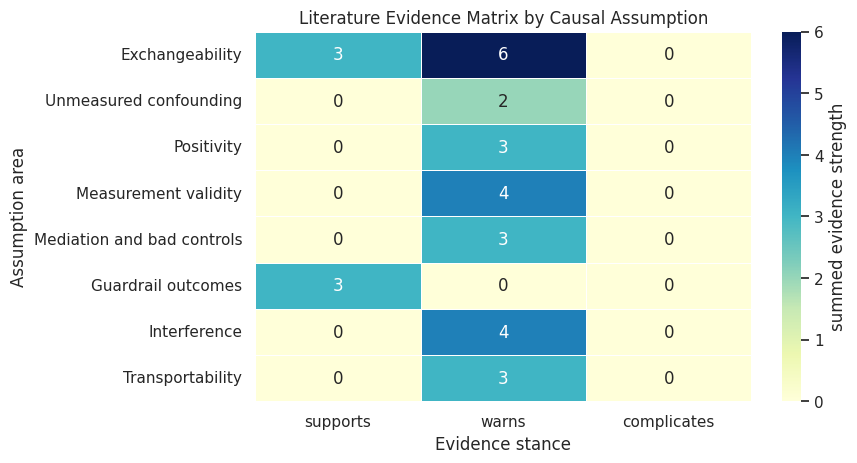

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.8))
sns.heatmap(matrix, annot=True, fmt='.0f', cmap='YlGnBu', linewidths=0.5, ax=ax, cbar_kws={'label': 'summed evidence strength'})
ax.set_title('Literature Evidence Matrix by Causal Assumption')
ax.set_xlabel('Evidence stance')
ax.set_ylabel('Assumption area')
plt.show()


A heatmap is not a validity proof. It is a navigation device. It quickly shows where the literature raises the most design risk. In this example, exchangeability and measurement validity deserve special attention before the analyst estimates the effect.

Read the plot as a diagnostic for the workflow. The main question is what visible pattern would change the analysis in Evidence Matrix. The shape of the plot tells us how much caution the operating rule needs.


## 7. Literature Retrieval for Assumption Questions

Now we build a retrieval layer. The point is not to retrieve papers by topic alone. We retrieve evidence for specific causal assumptions.


In [11]:
def normalize_whitespace(text):
    """Carry out the normalize whitespace step used in the 08. Literature Synthesis for Causal Assumptions workflow.
    
    Parameters
    ----------
    text : object
        Text produced or inspected by the language-model workflow.
    
    Returns
    -------
    object
        Intermediate result produced by the normalize whitespace calculation and reused by later cells.
    """
    return re.sub(r'\s+', ' ', text).strip()

lit_chunks = lit.copy()
lit_chunks['chunk_id'] = lit_chunks['source_id'] + '::abstract'
lit_chunks['text_for_retrieval'] = (
    lit_chunks['title'] + '. ' + lit_chunks['source_type'] + '. ' + lit_chunks['design'] + '. ' + lit_chunks['population'] + '. ' + lit_chunks['text'].map(normalize_whitespace)
)
lit_chunks[['chunk_id', 'title', 'quality', 'text_for_retrieval']].head()


,chunk_id,title,quality,text_for_retrieval
0,lit_001_queue_pressure_adoption::abstract,Queue Pressure and Adoption of AI Triage Tools,medium,Queue Pressure and Adoption of AI Triage Tools. observational industry study. panel observational. large customer support queu...
1,lit_002_readiness_selection::abstract,Operational Readiness as a Selection Mechanism in Support Automation,medium,Operational Readiness as a Selection Mechanism in Support Automation. implementation study. mixed-methods implementation analy...
2,lit_003_deflection_mediation::abstract,Self-Service Deflection as a Mechanism for Workload Reduction,medium,Self-Service Deflection as a Mechanism for Workload Reduction. mechanism study. mediation-oriented observational analysis. dig...
3,lit_004_metric_drift::abstract,Metric Drift in AI Support Analytics,high,Metric Drift in AI Support Analytics. measurement report. metric audit. support analytics platforms. Changes in logging granul...
4,lit_005_guardrail_tradeoffs::abstract,Customer Experience Guardrails for Support Automation,medium,Customer Experience Guardrails for Support Automation. quasi-experimental evaluation. matched difference-in-differences. consu...


In Literature Retrieval for Assumption Questions, a polished answer is secondary. The design has to remain checkable.


In [12]:
# Section focus: 7. Literature Retrieval for Assumption Questions.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

class LiteratureRetriever:
    def __init__(self, frame, text_col='text_for_retrieval'):
        """Carry out the init step used in the 08. Literature Synthesis for Causal Assumptions workflow.
        
        Parameters
        ----------
        self : object
            Current object instance whose stored state is used by the method.
        frame : object
            Data frame containing the units evaluated by this helper.
        text_col : object
            Text produced or inspected by the language-model workflow.
        
        Returns
        -------
        object
            None. The function updates a plot, display object, or notebook state as its side effect.
        """
        self.frame = frame.reset_index(drop=True).copy()
        self.vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1, 2), stop_words='english')
        self.matrix = self.vectorizer.fit_transform(self.frame[text_col])

    def search(self, query, top_k=TOP_K):
        """Carry out the search step used in the 08. Literature Synthesis for Causal Assumptions workflow.
        
        Parameters
        ----------
        self : object
            Current object instance whose stored state is used by the method.
        query : object
            The query setting that controls the search calculation in this notebook.
        top_k : object
            The top k setting that controls the search calculation in this notebook.
        
        Returns
        -------
        object
            Fitted model, transformer, or configuration object from the search workflow.
        """
        query_vec = self.vectorizer.transform([query])
        scores = cosine_similarity(query_vec, self.matrix).ravel()
        order = np.argsort(scores)[::-1][:top_k]
        out = self.frame.iloc[order].copy()
        out['score'] = scores[order]
        return out[['chunk_id', 'source_id', 'title', 'year', 'quality', 'design', 'score', 'text']]

lit_retriever = LiteratureRetriever(lit_chunks)
query = 'pre-treatment confounders for AI assistant rollout workload queue pressure staffing readiness backlog manager request'
lit_retriever.search(query, top_k=6)


,chunk_id,source_id,title,year,quality,design,score,text
9,lit_010_manager_priority::abstract,lit_010_manager_priority,Manager Priority Requests as Proxies for Operational Urgency,2022,low,retrospective cohort,0.293718,"Manager requests for early access were associated with urgent operational pressure, strategic-account load, and upcoming staff..."
0,lit_001_queue_pressure_adoption::abstract,lit_001_queue_pressure_adoption,Queue Pressure and Adoption of AI Triage Tools,2024,medium,panel observational,0.242707,"Teams with higher prior ticket volume, larger baseline backlog, and more urgent manager requests adopted AI triage tools earli..."
7,lit_008_staffing_workload::abstract,lit_008_staffing_workload,"Staffing, Forecast Demand, and Support Workload Metrics",2020,medium,forecasting and staffing analysis,0.178178,Forecast demand and staffing levels strongly predict workload per active agent hour. Staffing plans are set before most softwa...
8,lit_009_external_validity::abstract,lit_009_external_validity,External Validity of AI Assistant Pilots,2024,medium,evidence synthesis,0.167141,"Small pilots often exclude escalations, new products, and low-readiness teams. The synthesis warns that pilot effects may not ..."
1,lit_002_readiness_selection::abstract,lit_002_readiness_selection,Operational Readiness as a Selection Mechanism in Support Automation,2023,medium,mixed-methods implementation analysis,0.138749,"Readiness checks, knowledge-base completeness, and agent training influenced when teams received automation features. Readines..."
5,lit_006_interference_agents::abstract,lit_006_interference_agents,Peer Learning and Spillovers in Agent-Facing AI Tools,2024,high,cluster field study,0.046604,Agents without direct tool access learned prompts and triage strategies from treated peers. The authors found spillovers acros...


Read Literature Retrieval for Assumption Questions as a draft from an unreliable assistant. The analyst should keep what can be checked and use the failure modes to improve prompts, schemas, or retrieval.


## 8. Causal Query Rewriting for Literature Search

Broad literature questions often retrieve broad summaries. We get better evidence by rewriting the synthesis question into assumption-specific searches.


In [13]:
def literature_query_rewrites(question):
    """Carry out the literature query rewrites step used in the 08. Literature Synthesis for Causal Assumptions workflow.
    
    Parameters
    ----------
    question : object
        Question text sent to retrieval, reasoning, or evaluation steps.
    
    Returns
    -------
    object
        Array-like values produced by the calculation.
    """
    return [
        f'exchangeability confounding pre-treatment variables queue pressure backlog staffing readiness manager request for {question}',
        f'positivity overlap eligibility strategic accounts readiness exclusion support queues for {question}',
        f'measurement validity metric drift logging changes workload deflection CSAT reopen rate for {question}',
        f'interference spillovers peer learning agents queues team exposure for {question}',
        f'post-treatment mediators bad controls deflection adoption self-service total effect for {question}',
        f'transportability external validity pilot exclusion enterprise escalation queue mix for {question}',
    ]

rewritten_lit_queries = literature_query_rewrites(synthesis_question)
pd.DataFrame({'rewrite_id': range(1, len(rewritten_lit_queries) + 1), 'query': rewritten_lit_queries})


,rewrite_id,query
0,1,exchangeability confounding pre-treatment variables queue pressure backlog staffing readiness manager request for What does pr...
1,2,positivity overlap eligibility strategic accounts readiness exclusion support queues for What does prior evidence imply about ...
2,3,measurement validity metric drift logging changes workload deflection CSAT reopen rate for What does prior evidence imply abou...
3,4,interference spillovers peer learning agents queues team exposure for What does prior evidence imply about the causal assumpti...
4,5,post-treatment mediators bad controls deflection adoption self-service total effect for What does prior evidence imply about t...
5,6,transportability external validity pilot exclusion enterprise escalation queue mix for What does prior evidence imply about th...


This step in Causal Query Rewriting for Literature Search is a reliability test. The analyst should be able to trace each claim back to evidence.


In [14]:
# Section focus: 8. Causal Query Rewriting for Literature Search.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def multi_query_literature_search(question, top_k_per_query=3, final_k=8):
    """Carry out the multi query literature search step used in the 08. Literature Synthesis for Causal Assumptions workflow.
    
    Parameters
    ----------
    question : object
        Question text sent to retrieval, reasoning, or evaluation steps.
    top_k_per_query : object
        The top k per query setting that controls the multi query literature search calculation in this notebook.
    final_k : object
        The final k setting that controls the multi query literature search calculation in this notebook.
    
    Returns
    -------
    object
        Fitted model, transformer, or configuration object from the multi query literature search workflow.
    """
    rows = []
    for rewrite_id, rewritten_query in enumerate(literature_query_rewrites(question), start=1):
        hits = lit_retriever.search(rewritten_query, top_k=top_k_per_query).copy()
        hits['rewrite_id'] = rewrite_id
        hits['rewritten_query'] = rewritten_query
        rows.append(hits)
    all_hits = pd.concat(rows, ignore_index=True)
    aggregated = (
        all_hits.groupby(['chunk_id', 'source_id', 'title', 'year', 'quality', 'design', 'text'], as_index=False)
        .agg(max_score=('score', 'max'), mean_score=('score', 'mean'), retrieved_by=('rewrite_id', lambda x: sorted(set(x))))
        .sort_values(['max_score', 'mean_score'], ascending=False)
        .head(final_k)
        .reset_index(drop=True)
    )
    return aggregated

retrieved_literature = multi_query_literature_search(synthesis_question, top_k_per_query=3, final_k=8)
retrieved_literature[['chunk_id', 'title', 'quality', 'max_score', 'retrieved_by', 'text']]


,chunk_id,title,quality,max_score,retrieved_by,text
0,lit_003_deflection_mediation::abstract,Self-Service Deflection as a Mechanism for Workload Reduction,medium,0.409660,"[2, 3, 4, 5, 6]",Ticket deflection and self-service resolution appear after assistant exposure and explain part of the workload change. The stu...
1,lit_005_guardrail_tradeoffs::abstract,Customer Experience Guardrails for Support Automation,medium,0.293103,"[3, 5]",Automation reduced some workload measures but effects on CSAT and reopen rate varied by issue complexity. The paper recommends...
2,lit_009_external_validity::abstract,External Validity of AI Assistant Pilots,medium,0.289217,"[2, 6]","Small pilots often exclude escalations, new products, and low-readiness teams. The synthesis warns that pilot effects may not ..."
3,lit_004_metric_drift::abstract,Metric Drift in AI Support Analytics,high,0.282465,[3],Changes in logging granularity can create apparent jumps in deflection and workload metrics. The report recommends separating ...
4,lit_007_overlap_enterprise::abstract,Automation Eligibility and Positivity in Enterprise Support Queues,medium,0.277820,"[2, 6]",Queues handling strategic accounts were often excluded from early automation because of compliance and escalation concerns. Th...
5,lit_006_interference_agents::abstract,Peer Learning and Spillovers in Agent-Facing AI Tools,high,0.268494,[4],Agents without direct tool access learned prompts and triage strategies from treated peers. The authors found spillovers acros...
6,lit_001_queue_pressure_adoption::abstract,Queue Pressure and Adoption of AI Triage Tools,medium,0.237594,"[1, 4, 5]","Teams with higher prior ticket volume, larger baseline backlog, and more urgent manager requests adopted AI triage tools earli..."
7,lit_010_manager_priority::abstract,Manager Priority Requests as Proxies for Operational Urgency,low,0.207591,[1],"Manager requests for early access were associated with urgent operational pressure, strategic-account load, and upcoming staff..."


The retrieved set should include evidence on rollout confounding, deflection as a mediator, measurement drift, guardrails, interference, and transportability. If one of those areas is missing, the retrieval layer should be revised before asking an LLM to synthesize.

Causal Query Rewriting for Literature Search should leave a clear trail from the business question to the causal assumptions and diagnostics.


## 9. Retrieval Evaluation

For teaching, we can hand-label expected sources for each assumption. In production, this becomes an evaluation set for the literature retrieval system.


In [15]:
# Section focus: 9. Retrieval Evaluation.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

literature_retrieval_tests = [
    {'case_id': 'exchangeability', 'query': 'prior volume backlog staffing readiness manager request confounding rollout workload', 'expected_source_ids': {'lit_001_queue_pressure_adoption', 'lit_002_readiness_selection', 'lit_008_staffing_workload', 'lit_010_manager_priority'}},
    {'case_id': 'bad_controls', 'query': 'deflection adoption self-service mediator bad control total effect', 'expected_source_ids': {'lit_003_deflection_mediation'}},
    {'case_id': 'measurement', 'query': 'metric drift logging granularity deflection workload measurement threat', 'expected_source_ids': {'lit_004_metric_drift'}},
    {'case_id': 'interference', 'query': 'peer learning spillovers queue team no interference', 'expected_source_ids': {'lit_006_interference_agents'}},
    {'case_id': 'transportability', 'query': 'pilot external validity escalation queue mix production rollout', 'expected_source_ids': {'lit_009_external_validity'}},
]

rows = []
for test in literature_retrieval_tests:
    retrieved = lit_retriever.search(test['query'], top_k=5)
    retrieved_ids = set(retrieved['source_id'])
    hits = retrieved_ids.intersection(test['expected_source_ids'])
    rows.append(
        {
            'case_id': test['case_id'],
            'expected_sources': ', '.join(sorted(test['expected_source_ids'])),
            'top_sources': ', '.join(retrieved['source_id'].head(5)),
            'hits': len(hits),
            'expected': len(test['expected_source_ids']),
            'recall_at_5': len(hits) / len(test['expected_source_ids']),
        }
    )

lit_retrieval_eval = pd.DataFrame(rows)
smart_display(lit_retrieval_eval)


,case_id,expected_sources,top_sources,hits,expected,recall_at_5
0,exchangeability,"lit_001_queue_pressure_adoption, lit_002_readiness_selection, lit_008_staffing_workload, lit_010_manager_priority","lit_010_manager_priority, lit_001_queue_pressure_adoption, lit_008_staffing_workload, lit_002_readiness_selection, lit_009_ext...",4,4,1.0
1,bad_controls,lit_003_deflection_mediation,"lit_003_deflection_mediation, lit_001_queue_pressure_adoption, lit_004_metric_drift, lit_010_manager_priority, lit_009_externa...",1,1,1.0
2,measurement,lit_004_metric_drift,"lit_004_metric_drift, lit_003_deflection_mediation, lit_008_staffing_workload, lit_005_guardrail_tradeoffs, lit_002_readiness_...",1,1,1.0
3,interference,lit_006_interference_agents,"lit_006_interference_agents, lit_001_queue_pressure_adoption, lit_009_external_validity, lit_008_staffing_workload, lit_010_ma...",1,1,1.0
4,transportability,lit_009_external_validity,"lit_009_external_validity, lit_001_queue_pressure_adoption, lit_008_staffing_workload, lit_006_interference_agents, lit_002_re...",1,1,1.0


Retrieval Evaluation should show whether the model can follow the evidence without overclaiming.


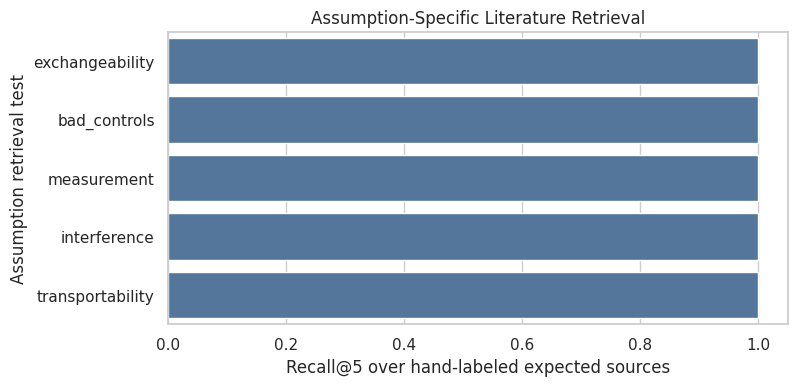

In [16]:
fig, ax = plt.subplots(figsize=(8, 3.8))
sns.barplot(data=lit_retrieval_eval, x='recall_at_5', y='case_id', color='#4776A6', ax=ax)
ax.set_xlim(0, 1.05)
ax.set_xlabel('Recall@5 over hand-labeled expected sources')
ax.set_ylabel('Assumption retrieval test')
ax.set_title('Assumption-Specific Literature Retrieval')
plt.show()


The evaluation in Retrieval Evaluation is less about style and more about whether the causal reasoning is controllable.


## 10. Format Literature Context for AI

The prompt should make the source boundary explicit. We include study metadata because quality, design, and population matter for causal interpretation.


In [17]:
# Section focus: 10. Format Literature Context for AI.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def format_literature_context(rows):
    """Format literature context for display in the 08. Literature Synthesis for Causal Assumptions notebook.
    
    Parameters
    ----------
    rows : object
        Single observation or record being converted, scored, or summarized.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the literature context workflow.
    """
    blocks = []
    for _, row in rows.iterrows():
        blocks.append(
            textwrap.dedent(
                f'''
                [source_id: {row['chunk_id']}]
                title: {row['title']}
                year: {row['year']}
                design: {row['design']}
                quality: {row['quality']}
                text: {row['text']}
                '''
            ).strip()
        )
    return '\n\n'.join(blocks)

literature_context = format_literature_context(retrieved_literature)
print(literature_context[:2500])


[source_id: lit_003_deflection_mediation::abstract]
title: Self-Service Deflection as a Mechanism for Workload Reduction
year: 2022
design: mediation-oriented observational analysis
quality: medium
text: Ticket deflection and self-service resolution appear after assistant exposure and explain part of the workload change. The study distinguishes total effects from direct effects and cautions against controlling for post-treatment deflection when estimating total effects. Deflection can be analyzed separately as a mechanism.

[source_id: lit_005_guardrail_tradeoffs::abstract]
title: Customer Experience Guardrails for Support Automation
year: 2023
design: matched difference-in-differences
quality: medium
text: Automation reduced some workload measures but effects on CSAT and reopen rate varied by issue complexity. The paper recommends treating CSAT and reopen rate as guardrail outcomes rather than adjustment variables. It emphasizes that guardrails should be reported even when the primary

Read the Format Literature Context for AI result as evidence for the next analytical move. The useful pattern is the one that changes a modeling choice, diagnostic priority, or operating guardrail.


## 11. Structured Literature Synthesis Schema

The model must not return a free-form essay. The schema forces source-grounded evidence, assumption-level ratings, caveats, and next actions.


In [18]:
# Section focus: 11. Structured Literature Synthesis Schema.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

ASSUMPTION_AREAS = [
    'Exchangeability',
    'Unmeasured confounding',
    'Positivity',
    'Measurement validity',
    'Mediation and bad controls',
    'Guardrail outcomes',
    'Interference',
    'Transportability',
]

class SourceClaim(BaseModel):
    source_id: str
    assumption_area: str
    claim: str
    stance: Literal['supports', 'warns', 'complicates', 'neutral']


class AssumptionSynthesis(BaseModel):
    assumption_area: str
    risk_level: Literal['low', 'medium', 'high', 'unclear']
    evidence_summary: str
    cited_source_ids: list[str] = Field(default_factory=list)
    design_implication: str


class LiteratureSynthesis(BaseModel):
    synthesis_question: str
    short_answer: str
    source_claims: list[SourceClaim] = Field(default_factory=list)
    assumption_summaries: list[AssumptionSynthesis] = Field(default_factory=list)
    evidence_gaps: list[str] = Field(default_factory=list)
    recommended_design_actions: list[str] = Field(default_factory=list)
    final_confidence: Literal['low', 'medium', 'high']


## 12. Deterministic Baseline Synthesis

Before using a model, create a baseline synthesis from the structured claim table. This gives us a reference answer that is easy to audit.


In [19]:
# Section focus: 12. Deterministic Baseline Synthesis.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def deterministic_literature_synthesis(question, claims_frame, retrieved_rows):
    """Carry out the deterministic literature synthesis step used in the 08. Literature Synthesis for Causal Assumptions workflow.
    
    Parameters
    ----------
    question : object
        Question text sent to retrieval, reasoning, or evaluation steps.
    claims_frame : object
        Tabular data object used as the input or output of this workflow step.
    retrieved_rows : object
        Single observation or record being converted, scored, or summarized.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the deterministic literature synthesis workflow.
    """
    retrieved_source_ids = set(retrieved_rows['source_id'])
    active_claims = claims_frame[claims_frame['source_id'].isin(retrieved_source_ids)].copy()
    source_claims = [
        SourceClaim(
            source_id=f"{row.source_id}::abstract",
            assumption_area=row.assumption,
            claim=row.claim,
            stance=row.stance,
        )
        for row in active_claims.itertuples()
    ]
    summaries = []
    for assumption in assumption_order:
        subset = active_claims[active_claims['assumption'] == assumption]
        if subset.empty:
            continue
        warns = (subset['stance'] == 'warns').sum()
        supports = (subset['stance'] == 'supports').sum()
        if warns >= 2 or subset['strength'].max() >= 4:
            risk = 'high'
        elif warns == 1:
            risk = 'medium'
        elif supports > 0:
            risk = 'low'
        else:
            risk = 'unclear'
        summaries.append(
            AssumptionSynthesis(
                assumption_area=assumption,
                risk_level=risk,
                evidence_summary='; '.join(subset['claim'].head(3)),
                cited_source_ids=[f'{sid}::abstract' for sid in subset['source_id'].tolist()],
                design_implication=(
                    'Treat this area as a required design review item before estimating the effect.'
                    if risk in {'medium', 'high'} else
                    'Document the supporting evidence and keep the assumption in the report.'
                ),
            )
        )
    return LiteratureSynthesis(
        synthesis_question=question,
        short_answer=(
            'The literature supports a cautious observational design. It highlights pre-treatment confounding, '
            'post-treatment mediator risk, measurement drift, guardrail reporting, and possible interference. '
            'It does not establish the causal effect for this project by itself.'
        ),
        source_claims=source_claims,
        assumption_summaries=summaries,
        evidence_gaps=[
            'Need direct evidence on overlap for the exact rollout population.',
            'Need project-specific metric lineage for workload, deflection, CSAT, and reopen rate.',
            'Need sensitivity analysis for unobserved urgency proxied by manager request.',
        ],
        recommended_design_actions=[
            'Pre-specify the total-effect estimand and exclude post-treatment mediators from adjustment.',
            'Adjust for pre-treatment demand, backlog, staffing, readiness, queue mix, and manager request where measured.',
            'Audit logging changes and report CSAT and reopen rate as guardrails.',
            'Assess spillovers at team or queue level before choosing the unit of analysis.',
        ],
        final_confidence='medium',
    )

baseline_synthesis = deterministic_literature_synthesis(synthesis_question, claims, retrieved_literature)
smart_display(baseline_synthesis)


LiteratureSynthesis(synthesis_question='What does prior evidence imply about the causal assumptions behind estimating the total effect of assistant enablement on human-handled workload and customer guardrails?', short_answer='The literature supports a cautious observational design. It highlights pre-treatment confounding, post-treatment mediator risk, measurement drift, guardrail reporting, and possible interference. It does not establish the causal effect for this project by itself.', source_claims=[SourceClaim(source_id='lit_001_queue_pressure_adoption::abstract', assumption_area='Exchangeability', claim='Early adoption is confounded by prior ticket volume, backlog, staffing, queue mix, and manager urgency.', stance='warns'), SourceClaim(source_id='lit_003_deflection_mediation::abstract', assumption_area='Mediation and bad controls', claim='Deflection is post-treatment and should not be controlled for in total-effect estimates.', stance='warns'), SourceClaim(source_id='lit_004_metric

For Deterministic Baseline Synthesis, treat the response as a small experiment in model behavior. Treat structure as useful and drift as evidence.


## 13. Optional Local LLM Synthesis

The live model receives the synthesis question, project design, and retrieved literature context. It is instructed to cite only retrieved source IDs and to avoid causal effect claims.


In [20]:
# Section focus: 13. Optional Local LLM Synthesis.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

from pathlib import Path
import sys


def find_project_root(start=None):
    """Carry out the find project root step used in the 08. Literature Synthesis for Causal Assumptions workflow.
    
    Parameters
    ----------
    start : object
        Starting index, time, or location for the simulated event window.
    
    Returns
    -------
    object
        Intermediate result produced by the find project root calculation and reused by later cells.
    """
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'notebooks').exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.local_llm import (
    DEFAULT_MODELS_TO_COMPARE,
    build_chat_inputs,
    clean_generated_text,
    clear_loaded_model_cache,
    decode_generated_response,
    format_chat_prompt,
    get_device,
    has_package,
    load_local_model as _shared_load_local_model,
    local_chat as _shared_local_chat,
    move_inputs_to_model_device,
    prepare_chat_inputs,
    set_generation_seed,
)

DEVICE = get_device()


def load_local_model(model_id=MODEL_ID):
    """Carry out the load local model step used in the 08. Literature Synthesis for Causal Assumptions workflow.
    
    Parameters
    ----------
    model_id : object
        Model object fitted, evaluated, or compared in this workflow.
    
    Returns
    -------
    object
        Fitted model, transformer, or configuration object from the load local model workflow.
    """
    return _shared_load_local_model(model_id)


def decode_generated_text(tokenizer, generated, prompt_token_count, model_id=MODEL_ID):
    """Carry out the decode generated text step used in the 08. Literature Synthesis for Causal Assumptions workflow.
    
    Parameters
    ----------
    tokenizer : object
        Tokenizer paired with the local language model for prompt encoding and decoding.
    generated : object
        Rate or probability parameter controlling this calculation.
    prompt_token_count : object
        Prompt text sent to the local language model in the live experiment.
    model_id : object
        Model object fitted, evaluated, or compared in this workflow.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the decode generated text workflow.
    """
    return decode_generated_response(tokenizer, generated, prompt_token_count, model_id=model_id)


def local_chat(user_message, system_message=None, model_id=MODEL_ID, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE):
    """Carry out the local chat step used in the 08. Literature Synthesis for Causal Assumptions workflow.
    
    Parameters
    ----------
    user_message : object
        User-facing prompt that asks the local language model to complete the task.
    system_message : object
        System instruction that sets the role and boundaries for the local language model.
    model_id : object
        Model object fitted, evaluated, or compared in this workflow.
    max_new_tokens : object
        Maximum number of generated tokens allowed for the local model response.
    temperature : object
        Sampling temperature controlling how deterministic the model response will be.
    
    Returns
    -------
    object
        Intermediate result produced by the local chat calculation and reused by later cells.
    """
    enabled = globals().get('RUN_LIVE_LOCAL_LLM', globals().get('RUN_LOCAL_LLM', True))
    return _shared_local_chat(
        user_message,
        system_message=system_message,
        model_id=model_id,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        seed=globals().get('SEED', 123),
        enabled=enabled,
    )


def local_generate(user_message, system_message=None, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE):
    """Carry out the local generate step used in the 08. Literature Synthesis for Causal Assumptions workflow.
    
    Parameters
    ----------
    user_message : object
        User-facing prompt that asks the local language model to complete the task.
    system_message : object
        System instruction that sets the role and boundaries for the local language model.
    max_new_tokens : object
        Maximum number of generated tokens allowed for the local model response.
    temperature : object
        Sampling temperature controlling how deterministic the model response will be.
    
    Returns
    -------
    object
        Intermediate result produced by the local generate calculation and reused by later cells.
    """
    return _shared_local_chat(
        user_message,
        system_message=system_message,
        model_id=MODEL_ID,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        seed=globals().get('SEED', 123),
        enabled=globals().get('RUN_LOCAL_LLM', globals().get('RUN_LIVE_LOCAL_LLM', True)),
    )


In [21]:
# Section focus: 13. Optional Local LLM Synthesis.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

SYSTEM_SYNTHESIS_MESSAGE = textwrap.dedent(
    '''
    You are a careful causal inference assistant synthesizing literature for causal assumptions.
    Use only the retrieved literature sources as evidence. Do not invent citations.
    Do not claim the assistant caused or reduced any outcome. The literature synthesis is design evidence, not an effect estimate.
    Return valid JSON only when asked for JSON.
    '''
).strip()

SYNTHESIS_PROMPT_TEMPLATE = textwrap.dedent(
    '''
    Synthesis question:
    {question}

    Project design:
    {project_design}

    Retrieved literature context:
    {context}

    Draft a literature synthesis for causal assumptions. Return valid JSON only with exactly these keys:
    synthesis_question, short_answer, source_claims, assumption_summaries, evidence_gaps,
    recommended_design_actions, final_confidence.

    source_claims must be an array of objects with keys:
    source_id, assumption_area, claim, stance.

    assumption_summaries must be an array of objects with keys:
    assumption_area, risk_level, evidence_summary, cited_source_ids, design_implication.

    Field requirements:
    - source_id values must be copied exactly from retrieved source_id lines.
    - cited_source_ids must contain only retrieved source_id values.
    - claim and evidence_summary must be strings, not booleans.
    - stance must be one of: supports, warns, complicates, neutral.
    - risk_level must be one of: low, medium, high, unclear.
    - final_confidence must be one of: low, medium, high.

    Causal safety requirements:
    - short_answer must say the literature does not estimate this project's causal effect by itself.
    - Cover exchangeability, measurement validity, mediation/bad controls, guardrails, interference, and transportability when evidence is available.
    - Phrase staffing, readiness, backlog, queue pressure, and manager request as possible pre-treatment confounders or design concerns, not as independence assumptions.
    - Include at least two evidence gaps and at least three recommended design actions.
    - Do not include markdown fences, prose before JSON, or prose after JSON.
    '''
).strip()

FALLBACK_SYNTHESIS_JSON = baseline_synthesis.model_dump_json(indent=2)


def synthesis_prompt(question=synthesis_question, rows=retrieved_literature):
    """Carry out the synthesis prompt step used in the 08. Literature Synthesis for Causal Assumptions workflow.
    
    Parameters
    ----------
    question : object
        Question text sent to retrieval, reasoning, or evaluation steps.
    rows : object
        Single observation or record being converted, scored, or summarized.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the synthesis prompt workflow.
    """
    return SYNTHESIS_PROMPT_TEMPLATE.format(
        question=question,
        project_design=json.dumps(project_design, indent=2),
        context=format_literature_context(rows),
    )


def literature_synthesis_llm(question=synthesis_question, rows=retrieved_literature, model_id=MODEL_ID):
    """Carry out the literature synthesis llm step used in the 08. Literature Synthesis for Causal Assumptions workflow.
    
    Parameters
    ----------
    question : object
        Question text sent to retrieval, reasoning, or evaluation steps.
    rows : object
        Single observation or record being converted, scored, or summarized.
    model_id : object
        Model object fitted, evaluated, or compared in this workflow.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the literature synthesis llm workflow.
    """
    if RUN_LIVE_LOCAL_LLM:
        return local_chat(
            synthesis_prompt(question, rows),
            system_message=SYSTEM_SYNTHESIS_MESSAGE,
            model_id=model_id,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
        )
    return FALLBACK_SYNTHESIS_JSON

raw_literature_synthesis = literature_synthesis_llm()
print(raw_literature_synthesis[:2200])


{
 "synthesis_question": "What does prior evidence imply about the causal assumptions behind estimating the total effect of assistant enablement on human-handled workload and customer guardrails?",
 "short_answer": "The literature does not estimate this project's causal effect by itself.",
 "source_claims": [
 {
 "source_id": "lit_003_deflection_mediation",
 "assumption_area": "mediation",
 "claim": "Ticket deflection and self-service resolution explain part of the workload change after assistant exposure.",
 "stance": "supports"
 },
 {
 "source_id": "lit_005_guardrail_tradeoffs",
 "assumption_area": "guardrails",
 "claim": "Guardrails like CSAT and reopen rate should be reported as outcomes rather than adjustment variables.",
 "stance": "warns"
 },
 {
 "source_id": "lit_009_external_validity",
 "assumption_area": "transportability",
 "claim": "Pilot effects may not transport to full production rollouts due to differences in agent training, queue mix, and customer segments.",
 "stance"

In Optional Local LLM Synthesis, the response is useful only if a human analyst can check it. Grounding matters here more than fluency; the response should show where each claim comes from.


## 14. Parse and Normalize Structured Synthesis

As before, parsing is not a mere convenience. It is the enforcement point that prevents free-form summaries from entering the analysis workflow without source IDs and assumption categories.


In [22]:
# Section focus: 14. Parse and Normalize Structured Synthesis.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def extract_json_object(text):
    """Extract the first JSON object from a model response for structured validation.
    
    Parameters
    ----------
    text : object
        Text produced or inspected by the language-model workflow.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the json object workflow.
    """
    cleaned = clean_generated_text(text)
    cleaned = re.sub(r'^```(?:json)?\s*', '', cleaned.strip())
    cleaned = re.sub(r'\s*```$', '', cleaned.strip())
    start = cleaned.find('{')
    end = cleaned.rfind('}')
    if start == -1 or end == -1 or end <= start:
        return None
    return cleaned[start : end + 1]


def text_from_generated_value(value, fallback='not specified'):
    """Carry out the text from generated value step used in the 08. Literature Synthesis for Causal Assumptions workflow.
    
    Parameters
    ----------
    value : object
        Single numeric or text value being checked, transformed, or displayed by this helper.
    fallback : object
        The fallback setting that controls the text from generated value calculation in this notebook.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the text from generated value workflow.
    """
    if value is None:
        return ''
    if isinstance(value, bool):
        return fallback
    if isinstance(value, (int, float)):
        return str(value)
    if isinstance(value, list):
        values = [text_from_generated_value(item, fallback=fallback) for item in value]
        return '; '.join(item for item in values if item)
    if isinstance(value, dict):
        source_id = value.get('source_id') or value.get('citation') or value.get('source') or ''
        for key in ['claim', 'evidence_summary', 'text', 'value', 'rationale', 'finding']:
            if key in value:
                text = text_from_generated_value(value[key], fallback='')
                if text:
                    return f'{text} Source: {source_id}.' if source_id and source_id not in text else text
        return f'Cited {source_id} without a specific text claim.' if source_id else json.dumps(value)
    return clean_generated_text(value)


def coerce_string_list(value):
    """Carry out the coerce string list step used in the 08. Literature Synthesis for Causal Assumptions workflow.
    
    Parameters
    ----------
    value : object
        Single numeric or text value being checked, transformed, or displayed by this helper.
    
    Returns
    -------
    object
        Array-like values produced by the calculation.
    """
    if value is None:
        return []
    if isinstance(value, list):
        items = value
    elif isinstance(value, str):
        items = re.split(r';|\n', value) if (';' in value or '\n' in value) else [value]
    else:
        items = [value]
    out = [text_from_generated_value(item, fallback='cited source without a specific text claim') for item in items]
    return [item for item in out if item]


def normalize_source_id(source_id, valid_source_ids):
    """Carry out the normalize source id step used in the 08. Literature Synthesis for Causal Assumptions workflow.
    
    Parameters
    ----------
    source_id : object
        The source id setting that controls the normalize source id calculation in this notebook.
    valid_source_ids : object
        Validation split or validation value used by this workflow.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    source_id = clean_generated_text(source_id)
    if source_id in valid_source_ids:
        return source_id, []
    compact = source_id.replace(' ', '').replace('`', '')
    if compact in valid_source_ids:
        return compact, [f'normalized source_id {source_id!r} to {compact!r}']
    for valid in valid_source_ids:
        if valid.startswith(source_id + '::') or source_id.startswith(valid.split('::')[0]):
            return valid, [f'mapped citation {source_id!r} to retrieved source {valid!r}']
    return source_id, []


def normalize_stance(value):
    """Carry out the normalize stance step used in the 08. Literature Synthesis for Causal Assumptions workflow.
    
    Parameters
    ----------
    value : object
        Single numeric or text value being checked, transformed, or displayed by this helper.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    stance = clean_generated_text(value).strip().lower().replace('-', '_').replace(' ', '_')
    if stance in {'supports', 'support'}:
        return 'supports', []
    if stance in {'warns', 'warning', 'risk'}:
        return 'warns', []
    if stance in {'complicates', 'complication', 'mixed'}:
        return 'complicates', []
    return 'neutral', [f'normalized stance {value!r} to neutral']


def normalize_risk(value):
    """Carry out the normalize risk step used in the 08. Literature Synthesis for Causal Assumptions workflow.
    
    Parameters
    ----------
    value : object
        Single numeric or text value being checked, transformed, or displayed by this helper.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    risk = clean_generated_text(value).strip().lower()
    if risk in {'low', 'medium', 'high', 'unclear'}:
        return risk, []
    if risk in {'moderate', 'mid'}:
        return 'medium', [f'normalized risk {value!r} to medium']
    return 'unclear', [f'normalized risk {value!r} to unclear']


def normalize_assumption_area(value):
    """Carry out the normalize assumption area step used in the 08. Literature Synthesis for Causal Assumptions workflow.
    
    Parameters
    ----------
    value : object
        Single numeric or text value being checked, transformed, or displayed by this helper.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    text = clean_generated_text(value).strip()
    lookup = {area.lower(): area for area in ASSUMPTION_AREAS}
    key = text.lower()
    if key in lookup:
        return lookup[key], []
    if 'confound' in key or 'exchange' in key:
        return 'Exchangeability', [f'normalized assumption area {value!r} to Exchangeability']
    if 'positiv' in key or 'overlap' in key:
        return 'Positivity', [f'normalized assumption area {value!r} to Positivity']
    if 'measure' in key or 'metric' in key or 'logging' in key:
        return 'Measurement validity', [f'normalized assumption area {value!r} to Measurement validity']
    if 'interference' in key or 'spillover' in key:
        return 'Interference', [f'normalized assumption area {value!r} to Interference']
    if 'mediat' in key or 'bad control' in key or 'post-treatment' in key:
        return 'Mediation and bad controls', [f'normalized assumption area {value!r} to Mediation and bad controls']
    if 'guardrail' in key or 'csat' in key or 'reopen' in key:
        return 'Guardrail outcomes', [f'normalized assumption area {value!r} to Guardrail outcomes']
    if 'transport' in key or 'external' in key:
        return 'Transportability', [f'normalized assumption area {value!r} to Transportability']
    return text or 'Unmeasured confounding', [f'kept uncommon assumption area {value!r}']


def normalize_source_claims(value, valid_source_ids):
    """Carry out the normalize source claims step used in the 08. Literature Synthesis for Causal Assumptions workflow.
    
    Parameters
    ----------
    value : object
        Single numeric or text value being checked, transformed, or displayed by this helper.
    valid_source_ids : object
        Validation split or validation value used by this workflow.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    notes = []
    if isinstance(value, dict):
        value = [{'source_id': key, **(val if isinstance(val, dict) else {'claim': val})} for key, val in value.items()]
        notes.append('coerced source_claims from object to list')
    if not isinstance(value, list):
        value = []
        notes.append('coerced invalid source_claims to empty list')
    out = []
    for idx, item in enumerate(value):
        if isinstance(item, str):
            item = {'source_id': '', 'assumption_area': 'Unmeasured confounding', 'claim': item, 'stance': 'neutral'}
            notes.append(f'coerced source_claims[{idx}] from string to object')
        item = dict(item)
        item.setdefault('source_id', item.get('citation') or item.get('source') or '')
        item.setdefault('assumption_area', item.get('assumption') or item.get('area') or 'Unmeasured confounding')
        item.setdefault('claim', item.get('text') or item.get('finding') or '')
        item.setdefault('stance', 'neutral')
        source_id, source_notes = normalize_source_id(item['source_id'], valid_source_ids)
        area, area_notes = normalize_assumption_area(item['assumption_area'])
        stance, stance_notes = normalize_stance(item['stance'])
        item['source_id'] = source_id
        item['assumption_area'] = area
        item['stance'] = stance
        item['claim'] = text_from_generated_value(item['claim'], fallback=f'Cited {source_id or "a source"} without a specific text claim.')
        notes.extend(f'source_claims[{idx}]: {note}' for note in source_notes + area_notes + stance_notes)
        out.append(item)
    return out, notes


def normalize_assumption_summaries(value, valid_source_ids):
    """Carry out the normalize assumption summaries step used in the 08. Literature Synthesis for Causal Assumptions workflow.
    
    Parameters
    ----------
    value : object
        Single numeric or text value being checked, transformed, or displayed by this helper.
    valid_source_ids : object
        Validation split or validation value used by this workflow.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    notes = []
    if isinstance(value, dict):
        value = [{'assumption_area': key, **(val if isinstance(val, dict) else {'evidence_summary': val})} for key, val in value.items()]
        notes.append('coerced assumption_summaries from object to list')
    if not isinstance(value, list):
        value = []
        notes.append('coerced invalid assumption_summaries to empty list')
    out = []
    for idx, item in enumerate(value):
        if isinstance(item, str):
            item = {'assumption_area': item, 'risk_level': 'unclear', 'evidence_summary': item, 'cited_source_ids': [], 'design_implication': 'Review manually.'}
            notes.append(f'coerced assumption_summaries[{idx}] from string to object')
        item = dict(item)
        item.setdefault('assumption_area', item.get('assumption') or item.get('area') or 'Unmeasured confounding')
        item.setdefault('risk_level', item.get('risk') or 'unclear')
        item.setdefault('evidence_summary', item.get('summary') or item.get('claim') or '')
        item.setdefault('cited_source_ids', item.get('sources') or [])
        item.setdefault('design_implication', item.get('implication') or item.get('next_step') or '')
        area, area_notes = normalize_assumption_area(item['assumption_area'])
        risk, risk_notes = normalize_risk(item['risk_level'])
        cited = []
        for source in coerce_string_list(item['cited_source_ids']):
            normalized, source_notes = normalize_source_id(source, valid_source_ids)
            cited.append(normalized)
            notes.extend(f'assumption_summaries[{idx}]: {note}' for note in source_notes)
        item['assumption_area'] = area
        item['risk_level'] = risk
        item['evidence_summary'] = text_from_generated_value(item['evidence_summary'], fallback='Evidence summary not specified.')
        item['cited_source_ids'] = list(dict.fromkeys(cited))
        item['design_implication'] = text_from_generated_value(item['design_implication'], fallback='Review manually.')
        notes.extend(f'assumption_summaries[{idx}]: {note}' for note in area_notes + risk_notes)
        out.append(item)
    return out, notes


def coerce_literature_synthesis(candidate, valid_source_ids):
    """Carry out the coerce literature synthesis step used in the 08. Literature Synthesis for Causal Assumptions workflow.
    
    Parameters
    ----------
    candidate : object
        Candidate action, variable, model, or explanation being compared.
    valid_source_ids : object
        Validation split or validation value used by this workflow.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    data = json.loads(candidate)
    notes = []
    for field in ['synthesis_question', 'short_answer', 'final_confidence']:
        data.setdefault(field, '')
        data[field] = clean_generated_text(data[field])
    confidence = data['final_confidence'].lower().strip()
    if confidence not in {'low', 'medium', 'high'}:
        notes.append(f'normalized final_confidence {data["final_confidence"]!r} to medium')
        confidence = 'medium'
    data['final_confidence'] = confidence
    source_claims, claim_notes = normalize_source_claims(data.get('source_claims', []), valid_source_ids)
    summaries, summary_notes = normalize_assumption_summaries(data.get('assumption_summaries', []), valid_source_ids)
    data['source_claims'] = source_claims
    data['assumption_summaries'] = summaries
    data['evidence_gaps'] = coerce_string_list(data.get('evidence_gaps', []))
    data['recommended_design_actions'] = coerce_string_list(data.get('recommended_design_actions', []))
    notes.extend(claim_notes + summary_notes)
    return json.dumps(data), notes


def parse_literature_synthesis(raw_output, valid_source_ids):
    """Carry out the parse literature synthesis step used in the 08. Literature Synthesis for Causal Assumptions workflow.
    
    Parameters
    ----------
    raw_output : object
        Raw text returned by the language model before parsing, scoring, or display.
    valid_source_ids : object
        Validation split or validation value used by this workflow.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    candidates = [clean_generated_text(raw_output)]
    extracted = extract_json_object(raw_output)
    if extracted is not None and extracted not in candidates:
        candidates.append(extracted)
    errors = []
    for candidate in candidates:
        try:
            parsed = LiteratureSynthesis.model_validate_json(candidate)
            normalized_candidate, normalization_notes = coerce_literature_synthesis(parsed.model_dump_json(), valid_source_ids)
            return LiteratureSynthesis.model_validate_json(normalized_candidate), normalized_candidate, errors + normalization_notes
        except ValidationError as error:
            errors.append(error.errors()[0]['msg'])
        except ValueError as error:
            errors.append(str(error).splitlines()[0])
        try:
            repaired_candidate, repair_notes = coerce_literature_synthesis(candidate, valid_source_ids)
            return LiteratureSynthesis.model_validate_json(repaired_candidate), repaired_candidate, errors + repair_notes
        except (TypeError, json.JSONDecodeError, ValidationError) as error:
            errors.append(str(error).splitlines()[0])
    raise ValueError(f'No valid LiteratureSynthesis found. Parser errors: {errors}')

valid_literature_source_ids = set(retrieved_literature['chunk_id'])
parsed_synthesis, synthesis_json_used, synthesis_parser_notes = parse_literature_synthesis(raw_literature_synthesis, valid_literature_source_ids)
if synthesis_parser_notes:
    print('Parser notes:')
    print(synthesis_parser_notes[:12])
smart_display(parsed_synthesis)


Parser notes:
["source_claims[0]: mapped citation 'lit_003_deflection_mediation' to retrieved source 'lit_003_deflection_mediation::abstract'", "source_claims[0]: normalized assumption area 'mediation' to Mediation and bad controls", "source_claims[1]: mapped citation 'lit_005_guardrail_tradeoffs' to retrieved source 'lit_005_guardrail_tradeoffs::abstract'", "source_claims[1]: normalized assumption area 'guardrails' to Guardrail outcomes", "source_claims[2]: mapped citation 'lit_009_external_validity' to retrieved source 'lit_009_external_validity::abstract'", "source_claims[3]: mapped citation 'lit_004_metric_drift' to retrieved source 'lit_004_metric_drift::abstract'", "assumption_summaries[0]: mapped citation 'lit_003_deflection_mediation' to retrieved source 'lit_003_deflection_mediation::abstract'", "assumption_summaries[0]: normalized assumption area 'mediation' to Mediation and bad controls", "assumption_summaries[1]: mapped citation 'lit_005_guardrail_tradeoffs' to retrieved so

LiteratureSynthesis(synthesis_question='What does prior evidence imply about the causal assumptions behind estimating the total effect of assistant enablement on human-handled workload and customer guardrails?', short_answer="The literature does not estimate this project's causal effect by itself.", source_claims=[SourceClaim(source_id='lit_003_deflection_mediation::abstract', assumption_area='Mediation and bad controls', claim='Ticket deflection and self-service resolution explain part of the workload change after assistant exposure.', stance='supports'), SourceClaim(source_id='lit_005_guardrail_tradeoffs::abstract', assumption_area='Guardrail outcomes', claim='Guardrails like CSAT and reopen rate should be reported as outcomes rather than adjustment variables.', stance='warns'), SourceClaim(source_id='lit_009_external_validity::abstract', assumption_area='Transportability', claim='Pilot effects may not transport to full production rollouts due to differences in agent training, queue 

In Parse and Normalize Structured Synthesis, a good answer gives the analyst something to verify instead of a confident conclusion to accept.


## 15. Audit the AI Synthesis

A valid schema is not enough. The audit checks source validity, assumption coverage, causal overclaiming, and whether design actions follow from the evidence.


In [23]:
# Section focus: 15. Audit the AI Synthesis.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def synthesis_text(synthesis):
    """Carry out the synthesis text step used in the 08. Literature Synthesis for Causal Assumptions workflow.
    
    Parameters
    ----------
    synthesis : object
        The synthesis setting that controls the synthesis text calculation in this notebook.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the synthesis text workflow.
    """
    parts = [synthesis.short_answer]
    parts.extend(claim.claim for claim in synthesis.source_claims)
    parts.extend(summary.evidence_summary for summary in synthesis.assumption_summaries)
    parts.extend(summary.design_implication for summary in synthesis.assumption_summaries)
    parts.extend(synthesis.evidence_gaps)
    parts.extend(synthesis.recommended_design_actions)
    return clean_generated_text(' '.join(parts)).lower()


def audit_literature_synthesis(synthesis, retrieved_rows):
    """Carry out the audit literature synthesis step used in the 08. Literature Synthesis for Causal Assumptions workflow.
    
    Parameters
    ----------
    synthesis : object
        The synthesis setting that controls the audit literature synthesis calculation in this notebook.
    retrieved_rows : object
        Single observation or record being converted, scored, or summarized.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    valid_ids = set(retrieved_rows['chunk_id'])
    issues = []
    cited_claim_ids = [claim.source_id for claim in synthesis.source_claims]
    cited_summary_ids = [sid for summary in synthesis.assumption_summaries for sid in summary.cited_source_ids]
    for source_id in cited_claim_ids + cited_summary_ids:
        if source_id not in valid_ids:
            issues.append({'area': 'citation', 'issue': 'citation not present in retrieved literature context', 'detail': source_id})
    if len(set(cited_claim_ids).intersection(valid_ids)) < 4:
        issues.append({'area': 'citation', 'issue': 'fewer than four valid source claims', 'detail': ', '.join(cited_claim_ids)})

    text = synthesis_text(synthesis)
    overclaim_patterns = [
        'proves the assistant caused',
        'establishes the causal effect',
        'assistant caused workload reduction',
        'assistant reduced workload',
        'literature proves',
    ]
    for pattern in overclaim_patterns:
        if pattern in text:
            issues.append({'area': 'causal overclaim', 'issue': 'unsupported causal certainty', 'detail': pattern})

    required_areas = {'Exchangeability', 'Measurement validity', 'Mediation and bad controls', 'Guardrail outcomes'}
    covered_areas = {summary.assumption_area for summary in synthesis.assumption_summaries}.union({claim.assumption_area for claim in synthesis.source_claims})
    for area in sorted(required_areas - covered_areas):
        issues.append({'area': 'coverage', 'issue': 'required assumption area missing', 'detail': area})

    if not any('does not' in synthesis.short_answer.lower() or 'not estimate' in synthesis.short_answer.lower() for _ in [0]):
        issues.append({'area': 'abstention', 'issue': 'short answer does not clearly separate literature synthesis from effect estimation', 'detail': ''})

    if not synthesis.evidence_gaps:
        issues.append({'area': 'evidence gaps', 'issue': 'no evidence gaps listed', 'detail': ''})
    if len(synthesis.recommended_design_actions) < 3:
        issues.append({'area': 'design actions', 'issue': 'fewer than three recommended design actions', 'detail': ''})

    return pd.DataFrame(issues, columns=['area', 'issue', 'detail'])

synthesis_audit = audit_literature_synthesis(parsed_synthesis, retrieved_literature)
smart_display(synthesis_audit)


,area,issue,detail
0,coverage,required assumption area missing,Exchangeability


The audit is intentionally conservative. A good synthesis should cite papers and explain their design implications. It should explain what each source means for the design and what remains uncertain.

For Audit the AI Synthesis, look for the places where the model helps the analyst and the places where the analyst has to push back.


## 16. Convert the Synthesis Into a Review Table

The table below is the shape a project lead can review: each assumption, risk level, evidence, citations, and design implication.


In [24]:
# Section focus: 16. Convert the Synthesis Into a Review Table.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def synthesis_review_table(synthesis):
    """Carry out the synthesis review table step used in the 08. Literature Synthesis for Causal Assumptions workflow.
    
    Parameters
    ----------
    synthesis : object
        The synthesis setting that controls the synthesis review table calculation in this notebook.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rows = []
    for summary in synthesis.assumption_summaries:
        rows.append(
            {
                'assumption_area': summary.assumption_area,
                'risk_level': summary.risk_level,
                'evidence_summary': summary.evidence_summary,
                'cited_source_ids': ', '.join(summary.cited_source_ids),
                'design_implication': summary.design_implication,
            }
        )
    return pd.DataFrame(rows)

review_table = synthesis_review_table(parsed_synthesis)
smart_display(review_table)


,assumption_area,risk_level,evidence_summary,cited_source_ids,design_implication
0,Mediation and bad controls,medium,"Deflection and self-service resolution are mechanisms explaining part of the workload change, suggesting they should be consid...",lit_003_deflection_mediation::abstract,Separate deflection and self-service resolution as mediators and consider their impact on the total effect.
1,Guardrail outcomes,medium,"Guardrails like CSAT and reopen rate should be reported as outcomes rather than adjustment variables, indicating potential con...",lit_005_guardrail_tradeoffs::abstract,Report guardrails as outcomes and avoid controlling for them in the primary analysis.
2,Transportability,high,"Pilot effects may not generalize to full production rollouts due to differences in agent training, queue mix, and customer seg...",lit_009_external_validity::abstract,Discuss transportability separately and ensure that the sample used for the analysis is representative of the target population.
3,Measurement validity,medium,"Changes in logging granularity can create apparent jumps in deflection and workload metrics, suggesting the need to separate t...",lit_004_metric_drift::abstract,Audit metric definitions and release dates to distinguish true behavior change from instrumentation change.


Use this table as a compact audit record. It shows which cases, segments, models, or assumptions carry the most weight in Convert the Synthesis Into a Review Table. A standout row deserves a second look before it becomes a conclusion.


## 17. Optional All-Model Comparison

Because these are live local model calls, the exact ranking may change across model versions, package versions, seeds, tokenizer behavior, prompt wording, and reruns. The durable lesson is the evaluation pattern, not the leaderboard. The table gives a concrete trace of how the assistant handled the task.

For literature synthesis, we score each model on schema reliability and causal usefulness. A high score requires valid citations, coverage of key assumption areas, explicit evidence gaps, and no causal overclaim.

In [25]:
# Section focus: 17. Optional All-Model Comparison.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

SYNTHESIS_EVAL_CASES = [
    {
        'case_id': 'assistant_assumption_synthesis',
        'question': synthesis_question,
        'retrieved_rows': retrieved_literature,
        'required_assumption_areas': {'Exchangeability', 'Measurement validity', 'Mediation and bad controls', 'Guardrail outcomes'},
        'required_source_ids': {'lit_001_queue_pressure_adoption::abstract', 'lit_003_deflection_mediation::abstract', 'lit_004_metric_drift::abstract'},
        'forbidden_phrases': ['assistant reduced workload', 'establishes the causal effect', 'literature proves'],
    },
]

SUMMARY_COLUMNS = ['label', 'model_id', 'role', 'cases', 'schema_valid_cases', 'schema_repaired_cases', 'schema_reliability', 'mean_synthesis_score', 'failure_types']
CASE_RESULT_COLUMNS = ['label', 'model_id', 'role', 'case_id', 'status', 'schema_valid', 'repair_used', 'repair_stage', 'error_type', 'synthesis_score', 'max_synthesis_score', 'synthesis_score_share', 'error']

SCHEMA_REPAIR_PROMPT_TEMPLATE = textwrap.dedent(
    '''
    Your previous answer could not be parsed as the required LiteratureSynthesis JSON schema.
    Convert the previous answer into valid JSON only. Do not add new causal claims.

    Parser error:
    {error_message}

    Previous answer:
    {raw_output}
    '''
).strip()


def classify_structured_output_failure(error):
    """Carry out the classify structured output failure step used in the 08. Literature Synthesis for Causal Assumptions workflow.
    
    Parameters
    ----------
    error : object
        Exception object or error label captured from a failed model or parsing step.
    
    Returns
    -------
    object
        Intermediate result produced by the classify structured output failure calculation and reused by later cells.
    """
    text = clean_generated_text(repr(error)).lower()
    if 'empty model output' in text:
        return 'empty_output'
    if 'field required' in text or 'missing' in text:
        return 'missing_required_field'
    if 'input should be' in text or 'validation error' in text:
        return 'wrong_field_type_or_schema'
    if 'invalid json' in text or 'expecting value' in text or 'eof' in text or 'jsondecodeerror' in text:
        return 'invalid_json_or_truncated_output'
    return 'other_structured_output_error'


def parse_or_repair_synthesis(raw_output, model_id, valid_source_ids):
    """Carry out the parse or repair synthesis step used in the 08. Literature Synthesis for Causal Assumptions workflow.
    
    Parameters
    ----------
    raw_output : object
        Raw text returned by the language model before parsing, scoring, or display.
    model_id : object
        Model object fitted, evaluated, or compared in this workflow.
    valid_source_ids : object
        Validation split or validation value used by this workflow.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    try:
        parsed, parsed_json, notes = parse_literature_synthesis(raw_output, valid_source_ids)
        return {'parsed': parsed, 'parsed_json': parsed_json, 'parser_notes': notes, 'repair_used': bool(notes), 'repair_stage': 'parser' if notes else 'none', 'repaired_raw_output': ''}
    except Exception as first_error:
        if not (RUN_SCHEMA_REPAIR_RETRY and RUN_LIVE_LOCAL_LLM):
            raise
        repair_prompt = SCHEMA_REPAIR_PROMPT_TEMPLATE.format(
            raw_output=clean_generated_text(raw_output)[:7000],
            error_message=clean_generated_text(repr(first_error))[:1200],
        )
        repaired_raw_output = local_chat(repair_prompt, system_message=SYSTEM_SYNTHESIS_MESSAGE, model_id=model_id, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE)
        parsed, parsed_json, notes = parse_literature_synthesis(repaired_raw_output, valid_source_ids)
        return {
            'parsed': parsed,
            'parsed_json': parsed_json,
            'parser_notes': [f'first_parse_error: {classify_structured_output_failure(first_error)}'] + notes,
            'repair_used': True,
            'repair_stage': 'model_retry',
            'repaired_raw_output': repaired_raw_output,
        }


def score_literature_synthesis(synthesis, retrieved_rows, case):
    """Score literature synthesis for the 08. Literature Synthesis for Causal Assumptions workflow.
    
    Parameters
    ----------
    synthesis : object
        The synthesis setting that controls the literature synthesis calculation in this notebook.
    retrieved_rows : object
        Single observation or record being converted, scored, or summarized.
    case : object
        Scenario record or dictionary being evaluated in the current notebook experiment.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    valid_ids = set(retrieved_rows['chunk_id'])
    cited_ids = {claim.source_id for claim in synthesis.source_claims}
    summary_ids = {sid for summary in synthesis.assumption_summaries for sid in summary.cited_source_ids}
    all_cited = cited_ids.union(summary_ids)
    text = synthesis_text(synthesis)
    covered_areas = {claim.assumption_area for claim in synthesis.source_claims}.union({summary.assumption_area for summary in synthesis.assumption_summaries})
    audit = audit_literature_synthesis(synthesis, retrieved_rows)
    checks = {
        'has short answer': bool(synthesis.short_answer.strip()),
        'short answer separates synthesis from effect estimation': 'does not' in synthesis.short_answer.lower() or 'not estimate' in synthesis.short_answer.lower(),
        'has at least four source claims': len(synthesis.source_claims) >= 4,
        'all cited sources are retrieved': all_cited.issubset(valid_ids),
        'contains required source': bool(set(case['required_source_ids']).intersection(all_cited)),
        'covers required assumption areas': set(case['required_assumption_areas']).issubset(covered_areas),
        'has assumption summaries': len(synthesis.assumption_summaries) >= 4,
        'has evidence gaps': len(synthesis.evidence_gaps) >= 2,
        'has design actions': len(synthesis.recommended_design_actions) >= 3,
        'avoids forbidden phrases': not any(phrase in text for phrase in case['forbidden_phrases']),
        'audit has no critical issues': audit.empty,
        'confidence is not high by default': synthesis.final_confidence in {'low', 'medium'},
    }
    return int(sum(checks.values())), len(checks), checks, audit


def evaluate_model_on_synthesis_case(label, model_id, role, case):
    """Evaluate model on synthesis case for the 08. Literature Synthesis for Causal Assumptions decision workflow.
    
    Parameters
    ----------
    label : object
        Human-readable label used to name a model, scenario, metric, or plotted series.
    model_id : object
        Model object fitted, evaluated, or compared in this workflow.
    role : object
        Workflow role assigned to an agent, variable, or review component.
    case : object
        Scenario record or dictionary being evaluated in the current notebook experiment.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    raw_output = repaired_raw_output = parsed_json = ''
    parser_notes = []
    checks = {}
    audit = pd.DataFrame()
    error = error_type = ''
    schema_valid = repair_used = False
    repair_stage = 'none'
    synthesis_score = np.nan
    max_synthesis_score = 12
    try:
        raw_output = local_chat(
            synthesis_prompt(case['question'], case['retrieved_rows']),
            system_message=SYSTEM_SYNTHESIS_MESSAGE,
            model_id=model_id,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
        )
        valid_source_ids = set(case['retrieved_rows']['chunk_id'])
        parse_result = parse_or_repair_synthesis(raw_output, model_id, valid_source_ids)
        parsed = parse_result['parsed']
        parsed_json = parse_result['parsed_json']
        parser_notes = parse_result['parser_notes']
        repair_used = parse_result['repair_used']
        repair_stage = parse_result['repair_stage']
        repaired_raw_output = parse_result['repaired_raw_output']
        synthesis_score, max_synthesis_score, checks, audit = score_literature_synthesis(parsed, case['retrieved_rows'], case)
        status = 'ok_after_repair' if repair_used else 'ok'
        schema_valid = True
        error_type = 'none'
    except Exception as exc:
        status = 'schema_error'
        error = clean_generated_text(repr(exc))[:500]
        error_type = classify_structured_output_failure(exc)
    return {
        'summary': {
            'label': label,
            'model_id': model_id,
            'role': role,
            'case_id': case['case_id'],
            'status': status,
            'schema_valid': schema_valid,
            'repair_used': repair_used,
            'repair_stage': repair_stage,
            'error_type': error_type,
            'synthesis_score': synthesis_score,
            'max_synthesis_score': max_synthesis_score,
            'synthesis_score_share': synthesis_score / max_synthesis_score if schema_valid else 0.0,
            'error': error,
        },
        'artifact': {
            'label': label,
            'model_id': model_id,
            'case_id': case['case_id'],
            'raw_output': raw_output,
            'repaired_raw_output': repaired_raw_output,
            'parsed_json': parsed_json,
            'parser_notes': parser_notes,
            'checks': checks,
            'audit': audit.to_dict(orient='records') if isinstance(audit, pd.DataFrame) else [],
        },
    }


def summarize_model_results(case_results):
    """Summarize model results for the 08. Literature Synthesis for Causal Assumptions analysis.
    
    Parameters
    ----------
    case_results : object
        Per-case outputs collected from model calls, rules, or diagnostics for comparison.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    if case_results.empty:
        return pd.DataFrame(columns=SUMMARY_COLUMNS)
    summary = (
        case_results.groupby(['label', 'model_id', 'role'], as_index=False)
        .agg(
            cases=('case_id', 'count'),
            schema_valid_cases=('schema_valid', 'sum'),
            schema_repaired_cases=('repair_used', 'sum'),
            mean_synthesis_score=('synthesis_score_share', lambda s: s.fillna(0).mean()),
            failure_types=('error_type', lambda values: ', '.join(sorted({v for v in values if v and v != 'none'}))),
        )
    )
    summary['schema_reliability'] = summary['schema_valid_cases'] / summary['cases']
    return summary[SUMMARY_COLUMNS].sort_values(['mean_synthesis_score', 'schema_reliability'], ascending=False).reset_index(drop=True)


def run_all_model_synthesis_comparison(models_to_compare=MODELS_TO_COMPARE):
    """Run the all model synthesis comparison workflow for the 08. Literature Synthesis for Causal Assumptions analysis.
    
    Parameters
    ----------
    models_to_compare : object
        Model object fitted, evaluated, or compared in this workflow.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    if not RUN_LIVE_LOCAL_LLM:
        raise RuntimeError('Set RUN_LIVE_LOCAL_LLM = True before running the model comparison.')
    active_cases = SYNTHESIS_EVAL_CASES[:MODEL_COMPARISON_CASE_LIMIT]
    rows = []
    artifacts = []
    for label, model_id, role in models_to_compare:
        print(f'Running {label}: {model_id}')
        for case in active_cases:
            result = evaluate_model_on_synthesis_case(label, model_id, role, case)
            rows.append(result['summary'])
            artifacts.append(result['artifact'])
        clear_loaded_model_cache()
    case_results = pd.DataFrame(rows, columns=CASE_RESULT_COLUMNS)
    model_summary = summarize_model_results(case_results)
    return case_results, model_summary, artifacts

if RUN_FULL_MODEL_COMPARISON:
    synthesis_case_results, synthesis_model_summary, synthesis_artifacts = run_all_model_synthesis_comparison()
else:
    synthesis_model_summary = pd.DataFrame(MODELS_TO_COMPARE, columns=['label', 'model_id', 'role'])
    synthesis_model_summary['cases'] = 0
    synthesis_model_summary['schema_valid_cases'] = 0
    synthesis_model_summary['schema_repaired_cases'] = 0
    synthesis_model_summary['schema_reliability'] = np.nan
    synthesis_model_summary['mean_synthesis_score'] = np.nan
    synthesis_model_summary['failure_types'] = ''
    synthesis_case_results = pd.DataFrame(columns=CASE_RESULT_COLUMNS)
    synthesis_artifacts = []
    smart_display(Markdown('All-model comparison is configured but not executed. Set `RUN_LIVE_LOCAL_LLM = True` and `RUN_FULL_MODEL_COMPARISON = True` in an interactive GPU session.'))

smart_display(synthesis_model_summary)


Running Qwen 0.5B: Qwen/Qwen2.5-0.5B-Instruct


Running Qwen 7B: Qwen/Qwen2.5-7B-Instruct


Running Qwen 14B: Qwen/Qwen2.5-14B-Instruct


Running Qwen 32B: Qwen/Qwen2.5-32B-Instruct


Running Phi mini: microsoft/Phi-3.5-mini-instruct


...

Running Mistral Small 24B: mistralai/Mistral-Small-3.1-24B-Instruct-2503


[transformers] The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Running Gemma 3 27B: google/gemma-3-27b-it


Running Llama 3.1 8B: meta-llama/Meta-Llama-3.1-8B-Instruct


,label,model_id,role,cases,schema_valid_cases,schema_repaired_cases,schema_reliability,mean_synthesis_score,failure_types
0,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,1,1,1,1.0,1.000000,
1,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,1,1,1,1.0,1.000000,
2,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,1,1,1,1.0,1.000000,
3,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,1,1,1,1.0,1.000000,
4,Phi mini,microsoft/Phi-3.5-mini-instruct,compact non-Qwen comparison,1,1,1,1.0,1.000000,
5,Qwen 14B,Qwen/Qwen2.5-14B-Instruct,strong local analysis,1,1,1,1.0,1.000000,
6,Qwen 32B,Qwen/Qwen2.5-32B-Instruct,scale comparison,1,1,1,1.0,1.000000,
7,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default,1,1,1,1.0,0.833333,
8,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,pipeline smoke test,1,1,1,1.0,0.416667,


Read Optional All-Model Comparison with a simple standard. The generated text has to preserve the design, not replace it.


### Inspecting Failed Model Runs

A failed model run now receives zero workflow credit in the summary table instead of producing a `NaN` score. The table below shows the exact failure metadata for those cases.

Two local model families need special handling in this environment: `Mistral Small 24B` is loaded with `Mistral3ForConditionalGeneration` plus a text tokenizer because its local text-only cache may not include image-processor files, and `Phi mini` is loaded with `LlamaTokenizerFast` plus `Phi3Config` because `AutoTokenizer` can hit a generic-config path in some Transformers builds. Those behaviors are now centralized in `notebooks/_shared/local_llm.py`.

In [26]:
failed_model_details = synthesis_case_results.loc[
    ~synthesis_case_results['schema_valid'],
    ['label', 'status', 'error_type', 'error'],
].reset_index(drop=True)
smart_display(failed_model_details)


,label,status,error_type,error


Read Inspecting Failed Model Runs as a draft from an unreliable assistant. This is useful only to the extent that the claims can be traced, tested, or repaired.


### Inspecting Failed Model Runs

A failed model run now receives zero workflow credit in the summary table instead of producing a `NaN` score. The table below shows the exact failure metadata for those cases.

Two local model families need special handling in this environment: `Mistral Small 24B` is loaded with `Mistral3ForConditionalGeneration` plus a text tokenizer because its local text-only cache may not include image-processor files, and `Phi mini` is loaded with `LlamaTokenizerFast` plus `Phi3Config` because `AutoTokenizer` can hit a generic-config path in some Transformers builds. Those behaviors are now centralized in `notebooks/_shared/local_llm.py`.

### Interpreting Repair Counts

Repairs are not failures by themselves. They show how much cleanup was needed before the output became usable.


In [27]:
def summarize_repair_stages(case_results):
    """Summarize repair stages for the 08. Literature Synthesis for Causal Assumptions analysis.
    
    Parameters
    ----------
    case_results : object
        Per-case outputs collected from model calls, rules, or diagnostics for comparison.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    if case_results.empty or 'repair_stage' not in case_results.columns:
        return pd.DataFrame(columns=['repair_stage', 'cases'])
    return (
        case_results.assign(repair_stage=case_results['repair_stage'].fillna('none'))
        .groupby('repair_stage', as_index=False)
        .agg(cases=('case_id', 'count'))
        .sort_values('cases', ascending=False)
    )

summarize_repair_stages(synthesis_case_results)


,repair_stage,cases
0,parser,9


For Interpreting Repair Counts, a strong answer stays inside the evidence, names uncertainty, and keeps assumptions separate from prose.


## 18. Human Review Checklist

A literature synthesis should be reviewed before it influences the causal design.


| area | question |
|---|---|
| source validity | Are all cited studies real, accessible, and correctly represented? |
| population match | Do study populations match the project population and support channels? |
| intervention match | Do prior tools resemble the assistant feature being evaluated? |
| assumption coverage | Does the synthesis cover exchangeability, positivity, measurement, interference, bad controls, and transportability? |
| effect overclaim | Does the synthesis avoid claiming the project effect from literature alone? |
| design actionability | Does each risk translate into data requirements, diagnostics, sensitivity checks, or reporting caveats? |
| evidence gaps | Are missing evidence areas explicit enough to guide next steps? |


## 19. Common Failure Modes

1. **Literature laundering**: citing a source for a claim it does not support.
2. **Vote counting**: treating the number of studies as more important than design fit.
3. **Effect overclaiming**: implying that prior literature identifies the project-specific effect.
4. **Population mismatch**: transporting pilot results to a very different production rollout.
5. **Bad-control confusion**: treating mechanisms such as deflection as ordinary controls.
6. **Measurement blindness**: ignoring metric drift, logging changes, or dashboard definition changes.
7. **Missing negative evidence**: summarizing only supportive studies and omitting warnings.


## 20. Key Takeaways

- Literature synthesis for causal inference should be organized by assumptions rather than topics alone.
- The most useful output is an assumption evidence matrix plus design implications.
- AI can help draft the synthesis, but it must cite sources and avoid project-specific causal effect claims.
- Retrieval, parsing, and audit layers are as important as the language model.
- Future notebooks will continue comparing all available local models whenever model behavior materially affects the workflow.


## References

- Lewis, P., Perez, E., Piktus, A., et al. (2020). Retrieval-augmented generation for knowledge-intensive NLP tasks. *arXiv*. [https://doi.org/10.48550/arXiv.2005.11401](https://doi.org/10.48550/arXiv.2005.11401)
- Hernan, M. A., & Robins, J. M. (2020). *Causal Inference: What If*. Chapman & Hall/CRC. [https://miguelhernan.org/whatifbook](https://miguelhernan.org/whatifbook)
- Pearl, J. (2009). *Causality: Models, Reasoning, and Inference* (2nd ed.). Cambridge University Press. [https://doi.org/10.1017/CBO9780511803161](https://doi.org/10.1017/CBO9780511803161)
- Imbens, G. W., & Rubin, D. B. (2015). *Causal Inference for Statistics, Social, and Biomedical Sciences*. Cambridge University Press. [https://doi.org/10.1017/CBO9781139025751](https://doi.org/10.1017/CBO9781139025751)
- Wei, J., Wang, X., Schuurmans, D., et al. (2022). Chain-of-thought prompting elicits reasoning in large language models. *arXiv*. [https://doi.org/10.48550/arXiv.2201.11903](https://doi.org/10.48550/arXiv.2201.11903)
